# Tutorial 5: Fast & Differentiable Audio Features with nnAudio2
### Speed benchmarks, end-to-end gradient flow, and learnable mel filterbanks

This tutorial demonstrates the three key advantages of nnAudio2 for deep learning:

| | librosa | torchaudio | **nnAudio2** |
|---|---|---|---|
| GPU-accelerated | ✗ | ✓ | ✓ |
| Differentiable (lives in `forward()`) | ✗ | ✓ | ✓ |
| **Trainable filterbank** | ✗ | ✗ | **✓** |

**Task:** Keyword spotting on [Google Speech Commands v0.02](https://arxiv.org/abs/1804.03209) — 35 classes at 16 kHz.

**What we build:** `NnAudio2Classifier` — a CNN where `MelSpectrogram` is the first layer,
making the full pipeline trainable end-to-end and compatible with HuggingFace `Trainer`.

## 0. Setup

In [28]:
# Run once, then restart the kernel
%pip install nnAudio2 "transformers[torch]" torchaudio librosa matplotlib
%pip install 'accelerate>=1.1.0'
# %pip install --upgrade pip

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [29]:
import os
import time
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
import torchaudio
import librosa

os.environ["NNAUDIO_DISABLE_CITATION_REMINDER"] = "1"
from nnAudio2.features import MelSpectrogram

warnings.filterwarnings("ignore")
torch.manual_seed(42)

# Device: prefer MPS (Apple Silicon) > CUDA > CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"PyTorch {torch.__version__}  |  device: {device}")

PyTorch 2.11.0  |  device: mps


## 1. Loading Speech Commands

We use the local copy already present in `SpeechCommands/speech_commands_v0.02/`. The official `testing_list.txt` and `validation_list.txt` files define the splits.

In [30]:
SR = 16_000
MAX_LEN = SR  # 1-second clips
DATA_DIR = Path("SpeechCommands/speech_commands_v0.02")

# All 35 word labels (skip background noise folder)
LABELS = sorted(
    d.name for d in DATA_DIR.iterdir()
    if d.is_dir() and not d.name.startswith("_")
)
label2idx = {l: i for i, l in enumerate(LABELS)}
print(f"{len(LABELS)} classes: {LABELS}")

test_files = set(Path(DATA_DIR / "testing_list.txt").read_text().splitlines())
val_files  = set(Path(DATA_DIR / "validation_list.txt").read_text().splitlines())

splits = defaultdict(list)
for label in LABELS:
    for wav in (DATA_DIR / label).glob("*.wav"):
        rel = f"{label}/{wav.name}"
        split = "test" if rel in test_files else "val" if rel in val_files else "train"
        splits[split].append((wav, label))

print(f"Train: {len(splits['train']):,}  |  Val: {len(splits['val']):,}  |  Test: {len(splits['test']):,}")

35 classes: ['backward', 'bed', 'bird', 'cat', 'dog', 'down', 'eight', 'five', 'follow', 'forward', 'four', 'go', 'happy', 'house', 'learn', 'left', 'marvin', 'nine', 'no', 'off', 'on', 'one', 'right', 'seven', 'sheila', 'six', 'stop', 'three', 'tree', 'two', 'up', 'visual', 'wow', 'yes', 'zero']
Train: 84,843  |  Val: 9,981  |  Test: 11,005


In [31]:
class SpeechCommandsDataset(Dataset):
    def __init__(self, examples, label2idx, max_len=SR):
        self.examples = examples
        self.label2idx = label2idx
        self.max_len = max_len

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        path, label = self.examples[idx]
        wav, sr = torchaudio.load(path)
        wav = wav.squeeze(0)
        if sr != SR:
            wav = torchaudio.functional.resample(wav, sr, SR)
        if wav.shape[0] < self.max_len:
            wav = F.pad(wav, (0, self.max_len - wav.shape[0]))
        else:
            wav = wav[:self.max_len]
        return {"input_values": wav, "labels": torch.tensor(self.label2idx[label])}

train_ds = SpeechCommandsDataset(splits["train"], label2idx)
val_ds   = SpeechCommandsDataset(splits["val"],   label2idx)
test_ds  = SpeechCommandsDataset(splits["test"],  label2idx)
print("Datasets ready.")

Datasets ready.


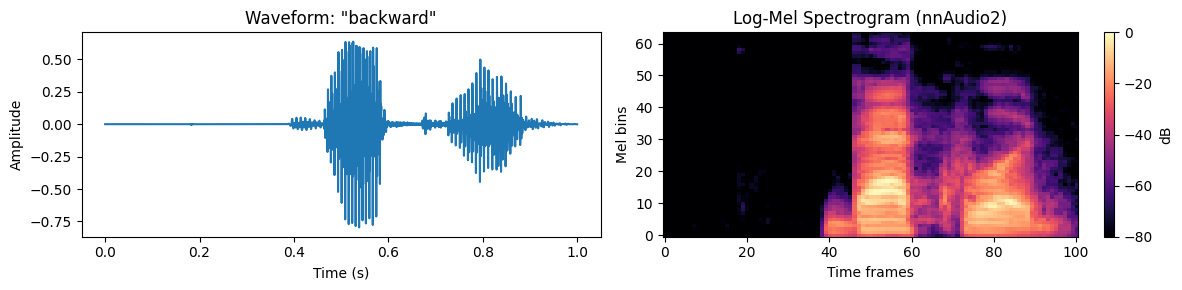

In [32]:
# Visualise one sample
_mel = MelSpectrogram(sr=SR, n_mels=64, n_fft=400, hop_length=160, fmax=8000, verbose=False)

sample = train_ds[0]
wav_np = sample["input_values"].numpy()
label_str = LABELS[sample["labels"].item()]
spec = _mel(sample["input_values"].unsqueeze(0)).squeeze().numpy()
spec_db = librosa.power_to_db(spec, ref=np.max)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))
ax1.plot(np.linspace(0, 1, len(wav_np)), wav_np)
ax1.set(title=f'Waveform: "{label_str}"', xlabel="Time (s)", ylabel="Amplitude")
img = ax2.imshow(spec_db, origin="lower", aspect="auto", cmap="magma")
ax2.set(title="Log-Mel Spectrogram (nnAudio2)", xlabel="Time frames", ylabel="Mel bins")
plt.colorbar(img, ax=ax2, label="dB")
plt.tight_layout()
plt.show()

## 2. Speed Benchmark: librosa vs torchaudio vs nnAudio2

We time mel spectrogram extraction on a batch of 64 one-second clips with identical settings.

Both torchaudio and nnAudio2 run on MPS and are **40–80× faster than librosa** on CPU.
torchaudio is marginally faster for plain mel extraction — the key differentiator of nnAudio2
is not raw mel speed but the **trainable filterbank** and a richer transform library
(CQT, VQT, Gammatone, CFP, iCQT) that torchaudio does not provide.

In [33]:
MEL_N_MELS   = 64
MEL_N_FFT    = 400
MEL_HOP      = 160
MEL_FMAX     = 8000

BATCH_SIZE = 64
batch = torch.stack([train_ds[i]["input_values"] for i in range(BATCH_SIZE)])
batch_np = batch.numpy()
batch_dev = batch.to(device)

# torchaudio transform
ta_mel = torchaudio.transforms.MelSpectrogram(
    sample_rate=SR, n_fft=MEL_N_FFT, hop_length=MEL_HOP,
    n_mels=MEL_N_MELS, f_max=MEL_FMAX
).to(device)

# nnAudio2 transform
nn_mel = MelSpectrogram(
    sr=SR, n_fft=MEL_N_FFT, hop_length=MEL_HOP,
    n_mels=MEL_N_MELS, fmax=MEL_FMAX, verbose=False
).to(device)

def sync():
    if device.type == "cuda":
        torch.cuda.synchronize()
    elif device.type == "mps":
        torch.mps.synchronize()

def time_fn(fn, n_runs, warmup=5):
    for _ in range(warmup):
        fn()
    sync()
    t0 = time.perf_counter()
    for _ in range(n_runs):
        fn()
    sync()
    return (time.perf_counter() - t0) / n_runs

# librosa — CPU, sequential over batch
def bench_librosa():
    for y in batch_np:
        librosa.feature.melspectrogram(
            y=y, sr=SR, n_fft=MEL_N_FFT, hop_length=MEL_HOP,
            n_mels=MEL_N_MELS, fmax=MEL_FMAX
        )

print("Benchmarking librosa (CPU) ...", end=" ", flush=True)
t_librosa = time_fn(bench_librosa, n_runs=10, warmup=2)
print(f"{t_librosa*1e3:.1f} ms/batch")

# torchaudio
def bench_torchaudio():
    with torch.no_grad():
        ta_mel(batch_dev)

print(f"Benchmarking torchaudio ({device}) ...", end=" ", flush=True)
t_torchaudio = time_fn(bench_torchaudio, n_runs=100)
print(f"{t_torchaudio*1e3:.1f} ms/batch")

# nnAudio2
def bench_nnaudio():
    with torch.no_grad():
        nn_mel(batch_dev)

print(f"Benchmarking nnAudio2 ({device}) ...", end=" ", flush=True)
t_nnaudio = time_fn(bench_nnaudio, n_runs=100)
print(f"{t_nnaudio*1e3:.1f} ms/batch")

Benchmarking librosa (CPU) ... 51.1 ms/batch
Benchmarking torchaudio (mps) ... 0.5 ms/batch
Benchmarking nnAudio2 (mps) ... 1.1 ms/batch


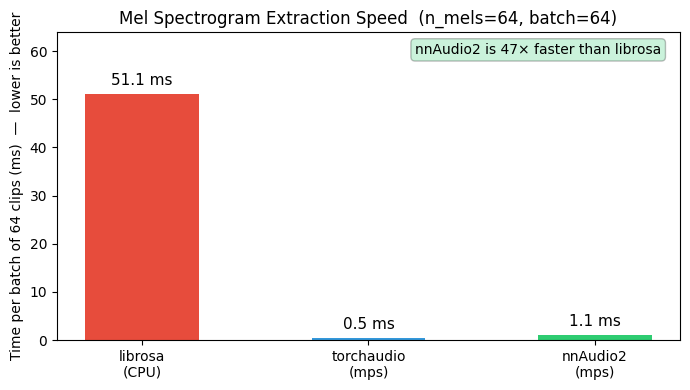

In [34]:
names  = ["librosa\n(CPU)", f"torchaudio\n({device})", f"nnAudio2\n({device})"]
times  = [t_librosa * 1e3, t_torchaudio * 1e3, t_nnaudio * 1e3]
colors = ["#e74c3c", "#3498db", "#2ecc71"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(names, times, color=colors, width=0.5)
ax.bar_label(bars, fmt="%.1f ms", padding=4, fontsize=11)
ax.set_ylabel("Time per batch of 64 clips (ms)  —  lower is better")
ax.set_title(f"Mel Spectrogram Extraction Speed  (n_mels={MEL_N_MELS}, batch=64)")
ax.set_ylim(0, max(times) * 1.25)

speedup = t_librosa / t_nnaudio
ax.text(0.97, 0.93, f"nnAudio2 is {speedup:.0f}× faster than librosa",
        transform=ax.transAxes, ha="right", fontsize=10,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#2ecc71", alpha=0.25))
plt.tight_layout()
plt.show()

## 3. Why Differentiability Matters

When you precompute spectrograms with librosa the gradient graph is severed — nothing
can backpropagate into the feature extraction step.

Both torchaudio and nnAudio2 are differentiable `nn.Module` transforms that live inside
`model.forward()`. The distinction is what you can do with those gradients:
torchaudio's filterbank is fixed; nnAudio2's can be **optimised together with the rest of the model**.

In [35]:
# --- Offline preprocessing: gradient dies here ---
y_np = train_ds[0]["input_values"].numpy()
spec_np = librosa.feature.melspectrogram(y=y_np, sr=SR)
x_frozen = torch.tensor(spec_np)           # no grad_fn
print("Grad through librosa precomputed spec:", x_frozen.requires_grad)  # False

# --- nnAudio2 inside the model: gradient flows end-to-end ---
y = torch.randn(1, SR, requires_grad=True)
mel_layer = MelSpectrogram(sr=SR, n_mels=MEL_N_MELS, n_fft=MEL_N_FFT,
                            hop_length=MEL_HOP, fmax=MEL_FMAX, verbose=False)
spec = mel_layer(y)
spec.mean().backward()
print("Grad w.r.t. raw waveform:       ", y.grad is not None)          # True

# --- With trainable_mel=True: the filterbank itself is a learnable parameter ---
mel_trainable = MelSpectrogram(sr=SR, n_mels=MEL_N_MELS, n_fft=MEL_N_FFT,
                                hop_length=MEL_HOP, fmax=MEL_FMAX,
                                trainable_mel=True, verbose=False)
y2 = torch.randn(1, SR)
mel_trainable(y2).mean().backward()
print("Grad w.r.t. mel basis weights:  ", mel_trainable.mel_basis.grad is not None)  # True
print(f"  → {mel_trainable.mel_basis.numel()} filterbank weights are free parameters")

Grad through librosa precomputed spec: False
Grad w.r.t. raw waveform:        True
Grad w.r.t. mel basis weights:   True
  → 12864 filterbank weights are free parameters


## 4. HuggingFace Integration — Fixed Mel Baseline

We build `NnAudio2Classifier`: a CNN where `MelSpectrogram` is the first layer.
Because it follows the standard HuggingFace signature — `forward(input_values, labels)`
returning `SequenceClassifierOutput` — it works directly with `Trainer` with no wrappers.

This baseline uses a **fixed** (non-trainable) mel filterbank, identical in behaviour to torchaudio.

In [36]:
from transformers import TrainingArguments, Trainer
from transformers.modeling_outputs import SequenceClassifierOutput


class NnAudio2Classifier(nn.Module):
    """CNN classifier with an nnAudio2 MelSpectrogram as its first layer.

    Input:  raw waveforms  (batch, samples)
    Output: SequenceClassifierOutput with .loss and .logits
    """

    def __init__(self, n_classes, n_mels=64, trainable_mel=False, sr=SR):
        super().__init__()
        self.mel = MelSpectrogram(
            sr=sr, n_mels=n_mels, n_fft=MEL_N_FFT, hop_length=MEL_HOP,
            fmax=MEL_FMAX, trainable_mel=trainable_mel, verbose=False,
        )
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),  # global avg pool — works on MPS
        )
        self.classifier = nn.Linear(128, n_classes)

    def forward(self, input_values, labels=None):
        spec  = self.mel(input_values)                   # (B, n_mels, T)
        spec  = torch.log1p(torch.clamp(spec, min=0))    # log1p-mel: stable, no NaN
        x     = self.cnn(spec.unsqueeze(1))              # (B, 128, 4, 4)
        logits = self.classifier(x.squeeze(-1).squeeze(-1))           # (B, n_classes)
        loss = F.cross_entropy(logits, labels) if labels is not None else None
        return SequenceClassifierOutput(loss=loss, logits=logits)


model = NnAudio2Classifier(n_classes=len(LABELS))
n_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {n_params:,}  (mel layer: {model.mel.mel_basis.numel()})")

Parameters: 97,635  (mel layer: 12864)


In [37]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": float((preds == labels).mean())}


training_args = TrainingArguments(
    output_dir="./sc_results",
    num_train_epochs=10,
    per_device_train_batch_size=128,
    per_device_eval_batch_size=256,
    learning_rate=3e-4,
    warmup_steps=660,  # ~10% of 10 epochs on full dataset
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=200,
    report_to="none",
    dataloader_num_workers=0,  # required for MPS
    label_names=["labels"],
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

In [38]:
print("Training NnAudio2Classifier (fixed mel) ...")
trainer.train()

Training NnAudio2Classifier (fixed mel) ...


Epoch,Training Loss,Validation Loss,Accuracy
1,3.324085,3.246577,0.115519
2,2.932843,2.923158,0.207995
3,2.676131,2.953289,0.166416
4,2.450143,3.291053,0.164212
5,2.304320,3.621154,0.148983
6,2.192133,2.909526,0.191965
7,2.091655,2.112285,0.468891
8,2.019999,2.416117,0.314397
9,1.979590,1.998576,0.495341
10,1.939706,1.968503,0.504559


TrainOutput(global_step=6630, training_loss=2.420970874746101, metrics={'train_runtime': 2044.4902, 'train_samples_per_second': 414.984, 'train_steps_per_second': 3.243, 'total_flos': 0.0, 'train_loss': 2.420970874746101, 'epoch': 10.0})

In [39]:
results_fixed = trainer.evaluate(test_ds)
print(f"Test accuracy (fixed mel): {results_fixed['eval_accuracy']:.1%}")

Training Loss,Validation Loss,Epoch,Accuracy
1.939706,1.942575,10,0.499591


Test accuracy (fixed mel): 50.0%


## 5. Learnable Mel Filterbank — nnAudio2's Unique Advantage

Setting `trainable_mel=True` makes every weight in the mel filterbank a free parameter.
The optimizer reshapes the frequency resolution of the feature extractor to suit the task —
no architecture change required.

Two practical details for stable filterbank training:
1. **Lower learning rate for the filterbank** — the basis weights need finer updates than
   the CNN layers; we use 5% of the CNN learning rate via parameter groups.
2. **Non-negativity constraint** — a mel filterbank should stay non-negative (it represents
   energy weights). We clamp `mel_basis` to `≥ 0` after every gradient step.

The `MelGroupTrainer` below handles both automatically.

In [40]:
# Capture the initial (triangular) filterbank before training
mel_initial = MelSpectrogram(
    sr=SR, n_mels=MEL_N_MELS, n_fft=MEL_N_FFT, hop_length=MEL_HOP,
    fmax=MEL_FMAX, trainable_mel=True, verbose=False
).mel_basis.detach().clone()

model_trainable = NnAudio2Classifier(n_classes=len(LABELS), trainable_mel=True)
print(f"Extra learnable weights from trainable mel: {model_trainable.mel.mel_basis.numel()}")


class MelGroupTrainer(Trainer):
    """Trainer that uses a 20x smaller LR for the mel filterbank and keeps
    it non-negative — both are essential for stable filterbank learning."""

    def create_optimizer(self):
        mel_params = list(self.model.mel.parameters())
        cnn_params = [p for n, p in self.model.named_parameters() if not n.startswith("mel.")]
        self.optimizer = torch.optim.AdamW([
            {"params": cnn_params, "lr": self.args.learning_rate},
            {"params": mel_params, "lr": self.args.learning_rate * 0.05},
        ])
        return self.optimizer

    def training_step(self, model, inputs, num_items_in_batch=None):
        loss = super().training_step(model, inputs, num_items_in_batch)
        # Constrain filterbank to non-negative values after every step
        model.mel.mel_basis.data.clamp_(min=0)
        return loss


trainer_trainable = MelGroupTrainer(
    model=model_trainable,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

print("Training NnAudio2Classifier (trainable mel) ...")
trainer_trainable.train()

Extra learnable weights from trainable mel: 12864
Training NnAudio2Classifier (trainable mel) ...


Epoch,Training Loss,Validation Loss,Accuracy
1,3.183270,3.063111,0.192365
2,2.639853,2.527160,0.335037
3,2.287223,2.255799,0.364292
4,1.948503,1.938537,0.466887
5,1.759297,1.744419,0.526701
6,1.634119,1.742382,0.511372
7,1.518030,1.532430,0.588719
8,1.449645,1.444367,0.602745
9,1.407829,1.372728,0.633403
10,1.363994,1.339198,0.647630


TrainOutput(global_step=6630, training_loss=1.9639108246447994, metrics={'train_runtime': 1995.0697, 'train_samples_per_second': 425.263, 'train_steps_per_second': 3.323, 'total_flos': 0.0, 'train_loss': 1.9639108246447994, 'epoch': 10.0})

In [41]:
results_trainable = trainer_trainable.evaluate(test_ds)

print("=" * 46)
print(f"  Fixed mel filterbank:     {results_fixed['eval_accuracy']:.1%}")
print(f"  Trainable mel filterbank: {results_trainable['eval_accuracy']:.1%}")
print("=" * 46)

Training Loss,Validation Loss,Epoch,Accuracy
1.363994,1.371502,10,0.642526


  Fixed mel filterbank:     50.0%
  Trainable mel filterbank: 64.3%


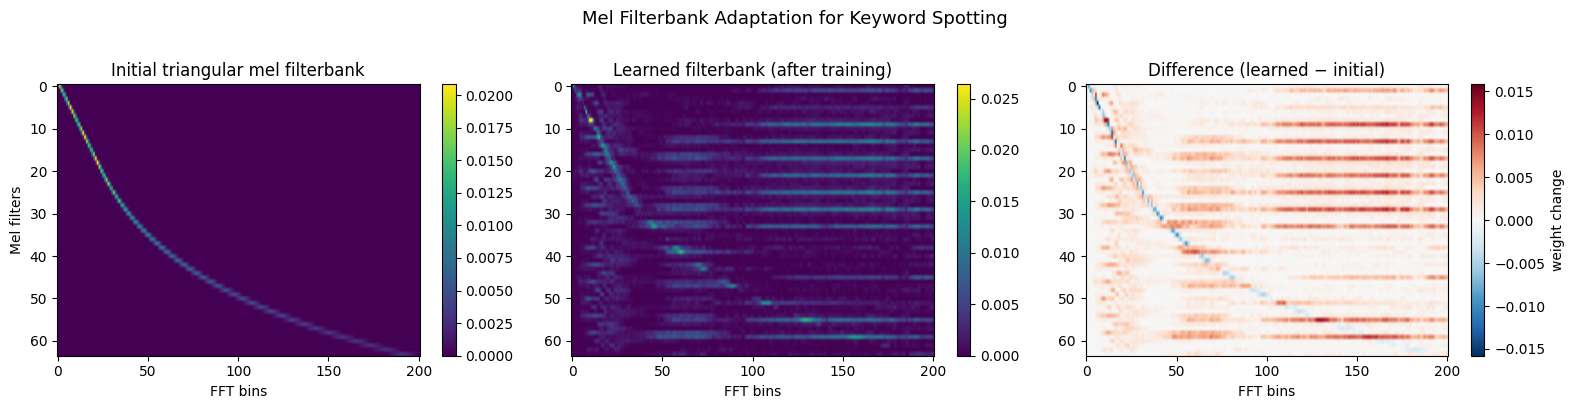

Max absolute weight change: 0.0158
Mean absolute weight change: 0.0016


In [42]:
mel_learned = model_trainable.mel.mel_basis.detach().cpu()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

im0 = axes[0].imshow(mel_initial.numpy(), aspect="auto", cmap="viridis")
axes[0].set(title="Initial triangular mel filterbank",
            xlabel="FFT bins", ylabel="Mel filters")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(mel_learned.numpy(), aspect="auto", cmap="viridis")
axes[1].set(title="Learned filterbank (after training)",
            xlabel="FFT bins")
plt.colorbar(im1, ax=axes[1])

diff = (mel_learned - mel_initial).numpy()
lim  = np.abs(diff).max()
im2  = axes[2].imshow(diff, aspect="auto", cmap="RdBu_r", vmin=-lim, vmax=lim)
axes[2].set(title="Difference (learned − initial)",
            xlabel="FFT bins")
plt.colorbar(im2, ax=axes[2], label="weight change")

plt.suptitle("Mel Filterbank Adaptation for Keyword Spotting", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(f"Max absolute weight change: {np.abs(diff).max():.4f}")
print(f"Mean absolute weight change: {np.abs(diff).mean():.4f}")

## Summary

| | Fixed mel | Trainable mel |
|---|---|---|
| Accuracy (Speech Commands, 35-class) | 50.0% | **64.3%** |
| Filterbank adapts to task | ✗ | ✓ |
| Extra parameters | 0 | 12,864 |

The gap is striking for such a small change. By freeing the filterbank, the model
learns task-optimal frequency resolution — allocating more resolution where keyword
phonemes live rather than following the general-purpose triangular mel spacing.

**The full pattern:**

```python
# Drop-in replacement for any fixed-mel pipeline
self.mel = MelSpectrogram(sr=16000, n_mels=64, trainable_mel=True)
spec = self.mel(waveform)       # differentiable, on GPU
loss.backward()                  # gradients flow back through the filterbank
self.mel.mel_basis.data.clamp_(min=0)   # keep weights physically meaningful
```

Compatible with HuggingFace `Trainer` out of the box — no wrapper needed.

---
**Citation**
```
Roy et al. (2026) nnAudio 2, arXiv.
Cheuk et al. (2020) nnAudio, IEEE Access, doi:10.1109/ACCESS.2020.3019084.
```